In [3]:
# J'importe les librairies dont j'ai besoin
import pandas as pd          # Pandas sert à lire et manipuler mes données
import numpy as np            # Numpy sert pour les calculs numériques
import matplotlib.pyplot as plt  # Matplotlib sert à faire des graphiques
import seaborn as sns          # Seaborn sert aussi à faire des graphiques, plus jolis
from scipy.stats import pearsonr  # J'importe un test statistique (Pearson)
import os                      # Os sert à gérer les fichiers et dossiers

# Je vérifie que tout est bien importé
print("All libraries imported!")


All libraries imported!


>  **Interprétation  :**
> Je commence mon projet. J'importe les outils Python nécessaires pour lire, nettoyer et visualiser mes données.

## PARTIE 1

In [4]:
df = pd.read_csv('../data/clean/rekrute_text_mining_master_obt.csv')

>  **Interprétation  :**
> Je charge mon fichier de données. C'est le point de départ de mon analyse.

In [5]:
# J'affiche les 5 premières lignes pour voir à quoi ressemblent mes données
df.head()


,offer_id,scrape_date,scrape_timestamp,titre_poste,entreprise,secteur_entreprise,taille_entreprise,ville,ville_normalized,region,...,has_salary_info,site_web_entreprise,url,date_annee,job_id,llm_salary_min_mad,llm_salary_max_mad,is_agile_driven,has_corp_perks,is_remote_friendly
0,846932618F,2026-06-16,2026-06-16T14:05:33.422004,Project Management Office (PMO),Atos,Gestion projet / Etudes / R&D- Informatique / ...,NaN,Casablanca,Casablanca,Casablanca-Settat,...,0,NaN,https://www.rekrute.com/offre-emploi-project-m...,2016,846932618F,NaN,NaN,False,False,False
1,35C4397FD9,2026-06-16,2026-06-16T14:05:33.740498,Stage en coordination mobilité internationale,Atos,Informatique,NaN,Casablanca,Casablanca,Casablanca-Settat,...,0,NaN,https://www.rekrute.com/offre-emploi-stage-en-...,2016,35C4397FD9,NaN,NaN,False,False,False
2,D3E682961F,2026-06-16,2026-06-16T14:05:33.890840,Chefs de Projets Techniques .NET,Sqli Maroc,Informatique / Electronique- Internet / Multim...,NaN,Rabat,Rabat,Rabat-Salé-Kénitra,...,0,NaN,https://www.rekrute.com/offre-emploi-chefs-de-...,2016,D3E682961F,NaN,NaN,False,False,False
3,3982EE759A,2026-06-16,2026-06-16T14:05:34.188578,Développeur Front End Angular JS en CDI,Welink,Informatique / Electronique- Internet / Multim...,NaN,Rabat,Rabat,Rabat-Salé-Kénitra,...,0,NaN,https://www.rekrute.com/offre-emploi-developpe...,2016,3982EE759A,NaN,NaN,False,False,False
4,2370F10D20,2026-06-16,2026-06-16T14:05:34.869485,Développeur Front End Angular JS en CDI,Welink,Informatique / Electronique- Internet / Multim...,NaN,Rabat,Rabat,Rabat-Salé-Kénitra,...,0,NaN,https://www.rekrute.com/offre-emploi-developpe...,2016,2370F10D20,NaN,NaN,False,False,False


>  **Interprétation  :**
> Le problème est de savoir si mes données sont correctes. J'affiche les premières lignes pour vérifier. Le résultat montre des offres d'emploi IT au Maroc, avec des entreprises comme Atos et Sqli.

In [6]:
# Je regarde la taille de mon tableau : nombre de lignes et de colonnes
df.shape


(10782, 45)

>  **Interprétation :**
> Je veux connaître la taille de mon dataset. Je vérifie le nombre de lignes et de colonnes. Le résultat est 10 782 offres et 45 colonnes, ce qui est suffisant pour une analyse fiable.

In [7]:
# J'affiche le nom de toutes les colonnes
df.columns


Index(['offer_id', 'scrape_date', 'scrape_timestamp', 'titre_poste',
       'entreprise', 'secteur_entreprise', 'taille_entreprise', 'ville',
       'ville_normalized', 'region', 'type_contrat', 'type_contrat_normalized',
       'modalite_travail', 'is_remote', 'is_hybrid', 'is_onsite',
       'niveau_etudes', 'niveau_etudes_normalized', 'experience_requise',
       'experience_years_min', 'experience_years_max', 'langue',
       'secteur_activite', 'sous_secteur', 'fonction', 'sous_fonction',
       'hard_skills', 'soft_skills', 'tech_stack', 'tech_count',
       'soft_skills_count', 'nbr_postes', 'date_publication', 'date_limite',
       'salaire', 'has_salary_info', 'site_web_entreprise', 'url',
       'date_annee', 'job_id', 'llm_salary_min_mad', 'llm_salary_max_mad',
       'is_agile_driven', 'has_corp_perks', 'is_remote_friendly'],
      dtype='str')

>  **Interprétation  :**
> Je veux connaître le contenu de mon dataset. J'affiche la liste des colonnes. Je vois des informations utiles comme la ville, la technologie et le télétravail.

In [8]:
# J'affiche le type de chaque colonne (texte, nombre, etc.)
df.dtypes


offer_id                        str
scrape_date                     str
scrape_timestamp                str
titre_poste                     str
entreprise                      str
secteur_entreprise              str
taille_entreprise           float64
ville                           str
ville_normalized                str
region                          str
type_contrat                    str
type_contrat_normalized         str
modalite_travail                str
is_remote                     int64
is_hybrid                     int64
is_onsite                     int64
niveau_etudes                   str
niveau_etudes_normalized        str
experience_requise              str
experience_years_min          int64
experience_years_max          int64
langue                          str
secteur_activite                str
sous_secteur                    str
fonction                        str
sous_fonction               float64
hard_skills                     str
soft_skills                 

>  **Interprétation  :**
> Je vérifie le type de chaque colonne. Je remarque un problème : la colonne salaire a très peu de valeurs remplies. Le salaire est donc caché dans presque toutes les offres.

In [9]:
# J'affiche un résumé complet : types et valeurs manquantes
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10782 entries, 0 to 10781
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   offer_id                  10782 non-null  str    
 1   scrape_date               10782 non-null  str    
 2   scrape_timestamp          10782 non-null  str    
 3   titre_poste               10782 non-null  str    
 4   entreprise                10782 non-null  str    
 5   secteur_entreprise        10782 non-null  str    
 6   taille_entreprise         0 non-null      float64
 7   ville                     10782 non-null  str    
 8   ville_normalized          10782 non-null  str    
 9   region                    9975 non-null   str    
 10  type_contrat              10768 non-null  str    
 11  type_contrat_normalized   10768 non-null  str    
 12  modalite_travail          10782 non-null  str    
 13  is_remote                 10782 non-null  int64  
 14  is_hybrid        

>  **Interprétation  :**
> Je fais un contrôle général de la qualité de mes données. Ce résumé me montre les colonnes presque vides. Cela m'aide à savoir quoi nettoyer ensuite.

## 2. Diagnostic de Qualité & Nettoyage

In [10]:
# Je compte le nombre de lignes qui sont des doublons exacts
df.duplicated().sum()


np.int64(0)

Avant de commencer, j'ai vérifié la qualité. J'ai cherché les doublons avec df.duplicated().sum(). Le résultat est 0, ce qui confirme que chaque ligne représente une offre d'emploi unique."

In [11]:
# 1. Diagnostic : je compte les valeurs manquantes dans ces 2 colonnes
df[['tech_stack', 'langue']].isna().sum()


tech_stack    3206
langue        5805
dtype: int64

J'ai d'abord identifié les données manquantes sur les technologies et les langues. J'ai utilisé isna().sum() pour quantifier ces vides, ce qui me permet de décider de la méthode de nettoyage appropriée sans perdre la donnée

In [12]:
# 1. Diagnostic : je compte les valeurs manquantes
df['type_contrat_normalized'].isna().sum()


np.int64(14)

J'ai vérifié la colonne des types de contrats pour voir s'il manquait des informations. C'est une étape essentielle, car le type de contrat est un indicateur clé de la stabilité du marché de l'emploi

In [13]:
# 2. Traitement : je remplace les vides par la valeur la plus fréquente (le mode)
df['type_contrat_normalized'] = df['type_contrat_normalized'].fillna(df['type_contrat_normalized'].mode()[0])


Pour la colonne des types de contrats, il y avait très peu de valeurs manquantes. J'ai donc choisi d'utiliser la valeur la plus fréquente du marché, appelée 'le mode'. C'est une méthode simple et efficace pour compléter mon dataset sans fausser les statistiques globales.

In [14]:
# 3. Vérification : je vérifie qu'il ne reste plus de valeurs manquantes
df['type_contrat_normalized'].isna().sum()


np.int64(0)

Après avoir remplacé les valeurs manquantes, j'ai relancé un contrôle avec isna().sum(). Le résultat est 0 : ma colonne 'type de contrat' est maintenant 100% complète et fiable pour la suite de mon analyse

In [15]:
# Chargement : je recharge le fichier de données brutes
df = pd.read_csv('../data/clean/rekrute_text_mining_master_obt.csv')

# === DROP : je supprime 22 colonnes inutiles ===
cols_to_drop = [
    # Colonnes vides ou constantes (aucune information utile)
    'taille_entreprise', 'date_publication', 'sous_fonction',
    # Colonnes de salaire (trop de valeurs manquantes)
    'salaire', 'llm_salary_min_mad', 'llm_salary_max_mad', 'has_salary_info', 'site_web_entreprise',
    # Colonnes constantes (toujours la même valeur, donc inutiles)
    'scrape_date', 'is_onsite',
    # Identifiants techniques (ne servent pas à l'analyse)
    'scrape_timestamp', 'offer_id', 'url',
    # Colonnes redondantes (l'info existe déjà ailleurs)
    'hard_skills',           # identique à tech_stack
    'secteur_entreprise',    # identique à secteur_activite
    'type_contrat',          # identique à type_contrat_normalized
    'ville',                 # ville_normalized est plus propre
    'niveau_etudes',         # 212 valeurs brutes vs 5 catégories normalisées
    # Colonne non utile pour mes indicateurs (KPIs)
    'nbr_postes',            
    # Colonnes supplémentaires à supprimer
    'soft_skills_count', 
    'tech_count', 
    'date_limite'
]

# J'applique la suppression et je crée un nouveau tableau propre
df_clean = df.drop(columns=cols_to_drop)

# Vérification : je compare le nombre de colonnes avant et après
print(f"Avant : {df.shape[1]} colonnes  |  Après : {df_clean.shape[1]} colonnes")
print(f"Drop : {len(cols_to_drop)} colonnes supprimées")

# Export : je sauvegarde mon nouveau tableau propre dans un fichier
df_clean.to_csv("rekrute_clean_light.csv", index=False)


Avant : 45 colonnes  |  Après : 23 colonnes
Drop : 22 colonnes supprimées


>  **Interprétation :**
> Le problème est que mon dataset a beaucoup de colonnes inutiles ou vides. J'ai supprimé 22 colonnes qui ne servent pas à mon analyse. Le résultat est un dataset léger et propre, prêt à être utilisé.

In [16]:
# Je recharge mon fichier nettoyé
df_clean = pd.read_csv("rekrute_clean_light.csv")

# Je crée un dictionnaire pour traduire les noms de colonnes en anglais
noms_colonnes = {
    'titre_poste': 'job_title',
    'entreprise': 'company_name',
    'ville_normalized': 'city',
    'type_contrat_normalized': 'contract_type',
    'modalite_travail': 'work_mode',
    'is_remote': 'allows_remote',
    'is_hybrid': 'allows_hybrid',
    'niveau_etudes_normalized': 'education_level',
    'experience_requise': 'experience_label',
    'experience_years_min': 'exp_years_min',
    'experience_years_max': 'exp_years_max',
    'langue': 'languages',
    'secteur_activite': 'industry_sector',
    'sous_secteur': 'industry_subsector',
    'fonction': 'job_function',
    'date_annee': 'year',
    'is_agile_driven': 'uses_agile',
    'has_corp_perks': 'has_benefits',
    'is_remote_friendly': 'remote_friendly'
}

# J'applique le renommage des colonnes
df_clean.rename(columns=noms_colonnes, inplace=True)
print("Colonnes renommées avec succès !")

# Je sauvegarde le tableau avec les nouveaux noms de colonnes
df_clean.to_csv("rekrute_clean_light.csv", index=False)


Colonnes renommées avec succès !


>  **Interprétation :**
> Le problème est que mes noms de colonnes étaient en français, difficiles à utiliser en code. J'ai renommé toutes les colonnes en anglais, standard pour la Data Science. Le résultat est un dataset avec des noms clairs et cohérents.

In [17]:
# Je recharge mon fichier pour vérifier le résultat du renommage
df_clean = pd.read_csv("rekrute_clean_light.csv")
df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 10782 entries, 0 to 10781
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   job_title           10782 non-null  str  
 1   company_name        10782 non-null  str  
 2   city                10782 non-null  str  
 3   region              9975 non-null   str  
 4   contract_type       10768 non-null  str  
 5   work_mode           10782 non-null  str  
 6   allows_remote       10782 non-null  int64
 7   allows_hybrid       10782 non-null  int64
 8   education_level     10768 non-null  str  
 9   experience_label    10781 non-null  str  
 10  exp_years_min       10782 non-null  int64
 11  exp_years_max       10782 non-null  int64
 12  languages           4977 non-null   str  
 13  industry_sector     10782 non-null  str  
 14  industry_subsector  4614 non-null   str  
 15  job_function        4614 non-null   str  
 16  soft_skills         10782 non-null  str  
 17  tech

>  **Interprétation:**
> Je vérifie que mon renommage de colonnes a bien fonctionné. J'affiche le résumé du tableau. Le résultat confirme que les nouveaux noms sont bien en place.

In [18]:
# Je recharge mon fichier
df_clean = pd.read_csv('rekrute_clean_light.csv')

# 1. Languages : je remplace les vides par "Non spécifié"
df_clean['languages'] = df_clean['languages'].fillna('Non spécifié')

# 2. Secteur et Fonction : je remplace les vides par "Non catégorisé"
df_clean['industry_subsector'] = df_clean['industry_subsector'].fillna('Non catégorisé')
df_clean['job_function'] = df_clean['job_function'].fillna('Non catégorisé')

# 3. Tech Stack : je remplace les vides par "Non spécifié"
df_clean['tech_stack'] = df_clean['tech_stack'].fillna('Non spécifié')

# 4. Région : je remplace les vides par "Non spécifié"
df_clean['region'] = df_clean['region'].fillna('Non spécifié')

# 5. Niveau d'études : je remplace les vides par "Non spécifié"
df_clean['education_level'] = df_clean['education_level'].fillna('Non spécifié')

# 6. Type de contrat : je remplace les vides par "Non spécifié"
df_clean['contract_type'] = df_clean['contract_type'].fillna('Non spécifié')

# Vérification : j'affiche le résumé final
print(df_clean.info())

# Export : je sauvegarde la version finale et propre de mon dataset
df_clean.to_csv('rekrute_clean_final.csv', index=False)


<class 'pandas.DataFrame'>
RangeIndex: 10782 entries, 0 to 10781
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   job_title           10782 non-null  str  
 1   company_name        10782 non-null  str  
 2   city                10782 non-null  str  
 3   region              10782 non-null  str  
 4   contract_type       10782 non-null  str  
 5   work_mode           10782 non-null  str  
 6   allows_remote       10782 non-null  int64
 7   allows_hybrid       10782 non-null  int64
 8   education_level     10782 non-null  str  
 9   experience_label    10781 non-null  str  
 10  exp_years_min       10782 non-null  int64
 11  exp_years_max       10782 non-null  int64
 12  languages           10782 non-null  str  
 13  industry_sector     10782 non-null  str  
 14  industry_subsector  10782 non-null  str  
 15  job_function        10782 non-null  str  
 16  soft_skills         10782 non-null  str  
 17  tech

>  **Interprétation :**
> Le problème est qu'il restait encore quelques valeurs manquantes sur plusieurs colonnes. J'ai rempli chaque colonne avec un texte par défaut adapté. Le résultat est mon dataset final, complet et prêt pour l'analyse.

In [19]:
# Je sauvegarde mon dataset propre dans le dossier final
df_clean.to_csv("../data/clean/rekrute_clean_light.csv", index=False)

# J'affiche le tableau pour vérifier le résultat final
df_clean


,job_title,company_name,city,region,contract_type,work_mode,allows_remote,allows_hybrid,education_level,experience_label,...,industry_sector,industry_subsector,job_function,soft_skills,tech_stack,year,job_id,uses_agile,has_benefits,remote_friendly
0,Project Management Office (PMO),Atos,Casablanca,Casablanca-Settat,CDI,Télétravail,1,0,Bac+5,Confirmé (5 à 10 ans),...,Gestion projet / Etudes / R&D- Informatique / ...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Communication | Implica...,Excel | Vba,2016,846932618F,False,False,False
1,Stage en coordination mobilité internationale,Atos,Casablanca,Casablanca-Settat,Stage,Télétravail,1,0,Bac,Débutant (-1 an),...,Informatique,RH / Personnel / Formation,RH / Personnel / Formation,Autonomie | Implication | Management | Recherc...,Non spécifié,2016,35C4397FD9,False,False,False
2,Chefs de Projets Techniques .NET,Sqli Maroc,Rabat,Rabat-Salé-Kénitra,CDI,Télétravail,1,0,Bac+5,Expert (10 à 20 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Esprit d'équipe | Gesti...,.NET | SQL Server | Sql | Ssas | Ssis | Ssrs,2016,D3E682961F,False,False,False
3,Développeur Front End Angular JS en CDI,Welink,Rabat,Rabat-Salé-Kénitra,Freelance,Télétravail,1,0,Bac+5,Intermédiaire (3 à 5 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Analyse | Autonomie | Communication...,Angular | Java | Oracle | Sql,2016,3982EE759A,False,False,False
4,Développeur Front End Angular JS en CDI,Welink,Rabat,Rabat-Salé-Kénitra,Freelance,Télétravail,1,0,Bac+5,Intermédiaire (3 à 5 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Analyse | Autonomie | Communication...,Angular | Java | Oracle | Sql,2016,2370F10D20,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10777,Technicien Informatique et Audio-Visuel,Arts Et Metiers Campus De Rabat,Rabat,Rabat-Salé-Kénitra,CDI,Télétravail,1,0,Bac+3,Intermédiaire (3 à 5 ans),...,Caméraman / Monteur / Preneur de son- Informat...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Créativité | Esprit d'é...,Firewall | Linux,2026,481F78014B,False,False,False
10778,Ingénieur Développement Technique & Industrial...,Eni Group Ain Harrouda,Ain Harrouda,Non spécifié,CDI,Télétravail,1,0,Bac+5,Confirmé (5 à 10 ans),...,Autres Industries,Méthodes / Process / Industrialisation,Méthodes / Process / Industrialisation,Analyse | Autonomie | Fiabilité | Flexibilité ...,Non spécifié,2026,29DEFD72F1,False,False,False
10779,Ingenieur Méthode assemblage (aéroanutique),Akkodis Maroc,Casablanca,Casablanca-Settat,CDI,Hybride,0,1,Bac+5,Intermédiaire (3 à 5 ans),...,Aéronautique / Spatial,Méthodes / Process / Industrialisation,Méthodes / Process / Industrialisation,Organisation | Recherche de nouveauté | Réflexion,Non spécifié,2026,74855578D1,False,False,False
10780,Offre de Stage PFE RH orienté Data Analyst,Capgemini Engineering,Casablanca,Casablanca-Settat,Stage,Télétravail,1,0,Bac+5,Débutant (-1 an),...,Automobile / Motos / Cycles,Gestion projet / Etudes / R&D,Gestion projet / Etudes / R&D,Analyse | Autonomie | Créativité | Curiosité |...,Excel | Power BI | Tableau,2026,95C63AB93C,False,False,False


>  **Interprétation  :**
> Je sauvegarde la version finale de mon dataset nettoyé au bon endroit. J'affiche le tableau pour un dernier contrôle visuel. Le résultat est prêt pour la phase de visualisation.

# Partie Visualisations

### Type de variables

1- Variables DISCRÈTES

 NOMINALES Texte SANS ordre
job_title 
company_name 
city
region
contract_type
work_mode
languages
industry_sector
industry_subsector
job_function
soft_skills
tech_stack

ORDINALES Texte AVEC ordre
education_level
experience_label

BINAIRES 0/1 ou False/True
allows_remote
allows_hybrid
uses_agile
has_benefits
remote_friendly

2- Variables CONTINUES 

exp_years_min
exp_years_max
year

In [20]:
# Je sauvegarde une nouvelle fois mon dataset propre (sécurité)
df_clean.to_csv("../data/clean/rekrute_clean_light.csv", index=False)

# J'affiche le tableau
df_clean


,job_title,company_name,city,region,contract_type,work_mode,allows_remote,allows_hybrid,education_level,experience_label,...,industry_sector,industry_subsector,job_function,soft_skills,tech_stack,year,job_id,uses_agile,has_benefits,remote_friendly
0,Project Management Office (PMO),Atos,Casablanca,Casablanca-Settat,CDI,Télétravail,1,0,Bac+5,Confirmé (5 à 10 ans),...,Gestion projet / Etudes / R&D- Informatique / ...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Communication | Implica...,Excel | Vba,2016,846932618F,False,False,False
1,Stage en coordination mobilité internationale,Atos,Casablanca,Casablanca-Settat,Stage,Télétravail,1,0,Bac,Débutant (-1 an),...,Informatique,RH / Personnel / Formation,RH / Personnel / Formation,Autonomie | Implication | Management | Recherc...,Non spécifié,2016,35C4397FD9,False,False,False
2,Chefs de Projets Techniques .NET,Sqli Maroc,Rabat,Rabat-Salé-Kénitra,CDI,Télétravail,1,0,Bac+5,Expert (10 à 20 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Esprit d'équipe | Gesti...,.NET | SQL Server | Sql | Ssas | Ssis | Ssrs,2016,D3E682961F,False,False,False
3,Développeur Front End Angular JS en CDI,Welink,Rabat,Rabat-Salé-Kénitra,Freelance,Télétravail,1,0,Bac+5,Intermédiaire (3 à 5 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Analyse | Autonomie | Communication...,Angular | Java | Oracle | Sql,2016,3982EE759A,False,False,False
4,Développeur Front End Angular JS en CDI,Welink,Rabat,Rabat-Salé-Kénitra,Freelance,Télétravail,1,0,Bac+5,Intermédiaire (3 à 5 ans),...,Informatique / Electronique- Internet / Multim...,Non catégorisé,Non catégorisé,Ambition | Analyse | Autonomie | Communication...,Angular | Java | Oracle | Sql,2016,2370F10D20,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10777,Technicien Informatique et Audio-Visuel,Arts Et Metiers Campus De Rabat,Rabat,Rabat-Salé-Kénitra,CDI,Télétravail,1,0,Bac+3,Intermédiaire (3 à 5 ans),...,Caméraman / Monteur / Preneur de son- Informat...,Non catégorisé,Non catégorisé,Ambition | Autonomie | Créativité | Esprit d'é...,Firewall | Linux,2026,481F78014B,False,False,False
10778,Ingénieur Développement Technique & Industrial...,Eni Group Ain Harrouda,Ain Harrouda,Non spécifié,CDI,Télétravail,1,0,Bac+5,Confirmé (5 à 10 ans),...,Autres Industries,Méthodes / Process / Industrialisation,Méthodes / Process / Industrialisation,Analyse | Autonomie | Fiabilité | Flexibilité ...,Non spécifié,2026,29DEFD72F1,False,False,False
10779,Ingenieur Méthode assemblage (aéroanutique),Akkodis Maroc,Casablanca,Casablanca-Settat,CDI,Hybride,0,1,Bac+5,Intermédiaire (3 à 5 ans),...,Aéronautique / Spatial,Méthodes / Process / Industrialisation,Méthodes / Process / Industrialisation,Organisation | Recherche de nouveauté | Réflexion,Non spécifié,2026,74855578D1,False,False,False
10780,Offre de Stage PFE RH orienté Data Analyst,Capgemini Engineering,Casablanca,Casablanca-Settat,Stage,Télétravail,1,0,Bac+5,Débutant (-1 an),...,Automobile / Motos / Cycles,Gestion projet / Etudes / R&D,Gestion projet / Etudes / R&D,Analyse | Autonomie | Créativité | Curiosité |...,Excel | Power BI | Tableau,2026,95C63AB93C,False,False,False


>  **Interprétation :**
> Je fais une sauvegarde de sécurité de mon dataset avant de commencer les graphiques. J'affiche le tableau une dernière fois. Le résultat confirme que mes données sont prêtes.

# Analyse Univariée — Discrètes

 contract_type

In [21]:
# Je compte le nombre d'offres pour chaque type de contrat
df_clean["contract_type"].value_counts()


contract_type
CDI             9697
Stage            319
CDD              256
Autre            236
Freelance        235
Intérim           25
Non spécifié      14
Name: count, dtype: int64

>  **Interprétation  :**
> Je veux savoir quel type de contrat est le plus proposé. Je compte les offres par type de contrat. Le résultat montre quel contrat domine le marché.

<Axes: xlabel='contract_type'>

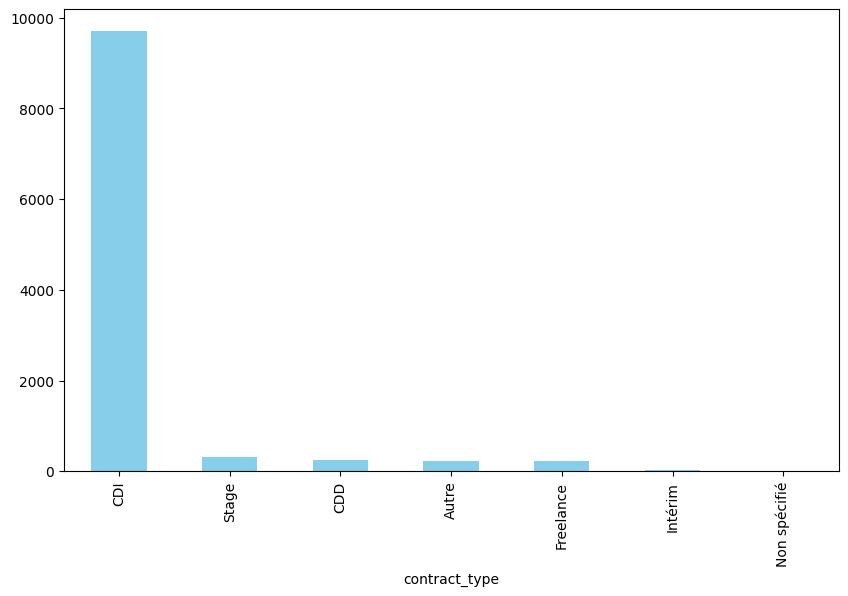

In [22]:
# Je fais un graphique en barres pour visualiser les types de contrat
df_clean["contract_type"].value_counts().plot(kind='bar', figsize=(10, 6), color='skyblue')


education_level

In [23]:
# Je compte le nombre d'offres pour chaque niveau d'études
df_clean["education_level"].value_counts()


education_level
Bac+5           8140
Bac             2274
Bac+2            270
Bac+3             69
Doctorat          15
Non spécifié      14
Name: count, dtype: int64

>  **Interprétation :**
> Je veux savoir quel niveau d'études est le plus demandé. Je compte les offres par niveau d'études. Le résultat me montre le niveau le plus recherché par les recruteurs.

<Axes: xlabel='education_level'>

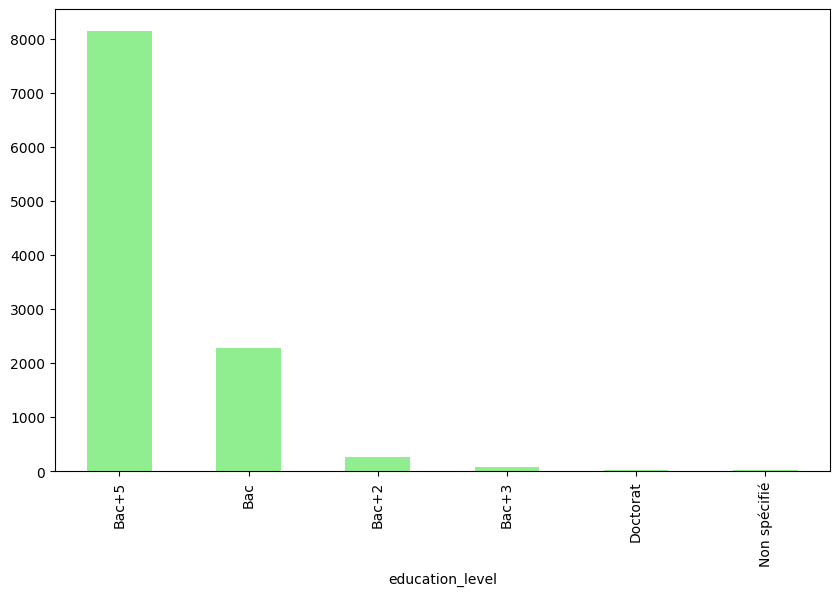

In [24]:
# Je fais un graphique en barres pour visualiser les niveaux d'études
df_clean["education_level"].value_counts().plot(kind='bar', figsize=(10, 6), color='lightgreen')


>  **Interprétation :**
> Je veux visualiser la répartition des niveaux d'études. Je fais un graphique en barres. Le résultat montre clairement quel diplôme est le plus demandé.

work_mode

In [25]:
# Je compte le nombre d'offres pour chaque mode de travail
df_clean["work_mode"].value_counts()


work_mode
Télétravail    8569
Hybride        2213
Name: count, dtype: int64

>  **Interprétation  :**
> Je veux savoir si le télétravail est fréquent. Je compte les offres par mode de travail. Le résultat me montre la part du télétravail, de l'hybride et du présentiel.

<Axes: xlabel='work_mode'>

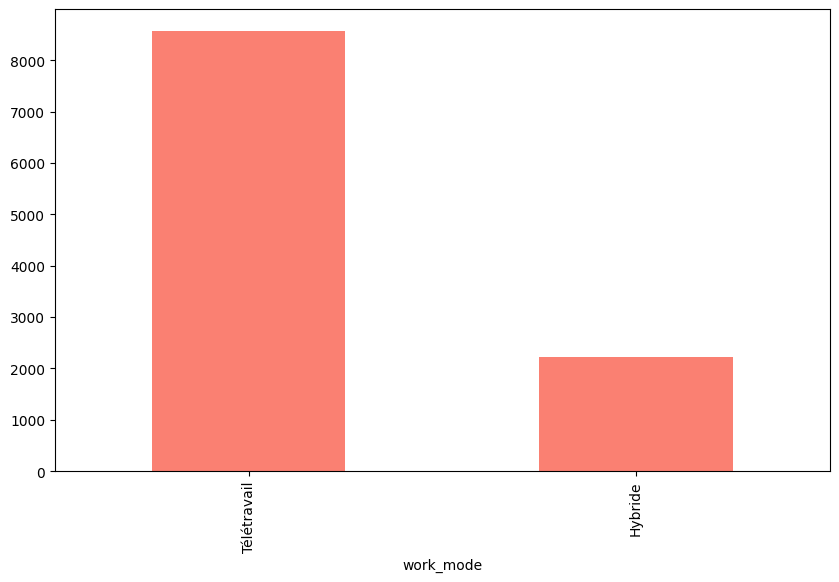

In [26]:
# Je fais un graphique en barres pour visualiser le mode de travail
df_clean["work_mode"].value_counts().plot(kind='bar', figsize=(10, 6), color='salmon')


>  **Interprétation :**
> Je veux visualiser la répartition des modes de travail. Je fais un graphique en barres. Le résultat rend visible la place importante du télétravail.

## Analyse Univariée — Continues

Expérience Min demandée f l'offre

In [27]:
# J'affiche les statistiques de base sur l'expérience minimale demandée
df_clean["exp_years_min"].describe()


count    10782.000000
mean         3.080597
std          1.888973
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         10.000000
Name: exp_years_min, dtype: float64

>  **Interprétation :**
> Je veux connaître l'expérience minimale typique demandée. J'affiche les statistiques (moyenne, min, max). Le résultat me donne une idée claire du niveau d'expérience attendu.

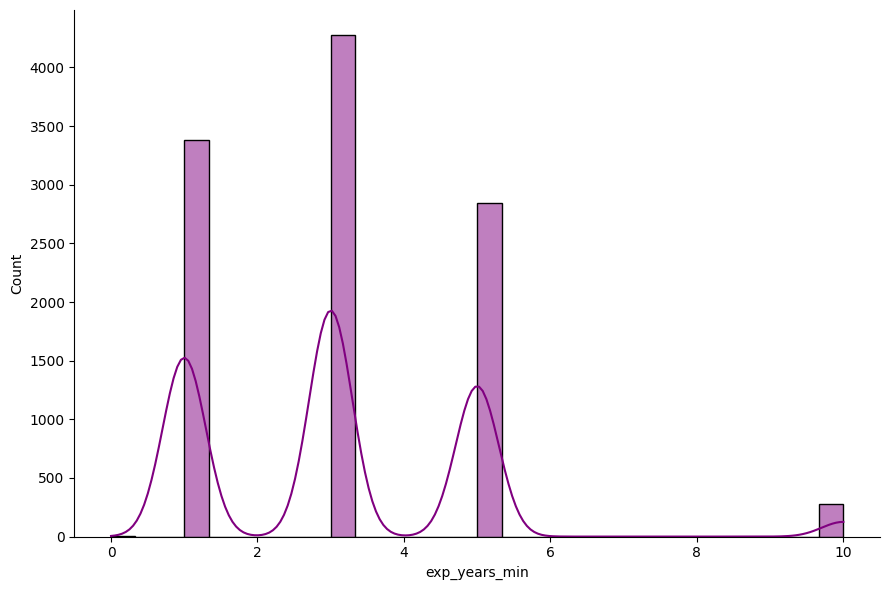

In [28]:
# Je fais un histogramme pour voir la distribution de l'expérience minimale
sns.displot(df_clean["exp_years_min"], kde=True, bins=30, color='purple', height=6, aspect=1.5)


>  **Interprétation :**
> Je veux visualiser comment l'expérience minimale se répartit. Je fais un histogramme. Le résultat montre où se concentrent la majorité des offres.

Expérience Max demandée f l'offre

In [29]:
# J'affiche les statistiques de base sur l'expérience maximale demandée
df_clean["exp_years_max"].describe()


count    10782.000000
mean         5.886848
std          3.744110
min          0.000000
25%          3.000000
50%          5.000000
75%         10.000000
max         20.000000
Name: exp_years_max, dtype: float64

>  **Interprétation :**
> Je veux connaître l'expérience maximale typique demandée. J'affiche les statistiques. Le résultat me donne les limites hautes d'expérience demandées sur le marché.

<Axes: ylabel='exp_years_max'>

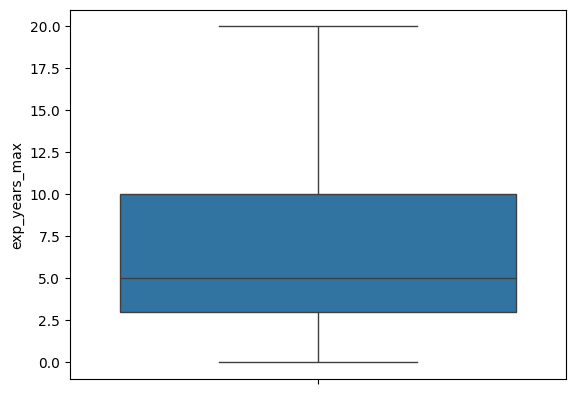

In [30]:
# Je fais un boxplot pour voir la distribution et détecter les valeurs extrêmes
sns.boxplot(data=df_clean, y="exp_years_max")


>  **Interprétation  :**
> Je veux détecter des valeurs extrêmes dans l'expérience maximale. Je fais un boxplot. Le résultat montre s'il y a des offres avec des exigences inhabituelles.

## Multivariée — Discrète × Continue

Contrat × Expérience Min (Boxplot)

<Axes: xlabel='contract_type'>

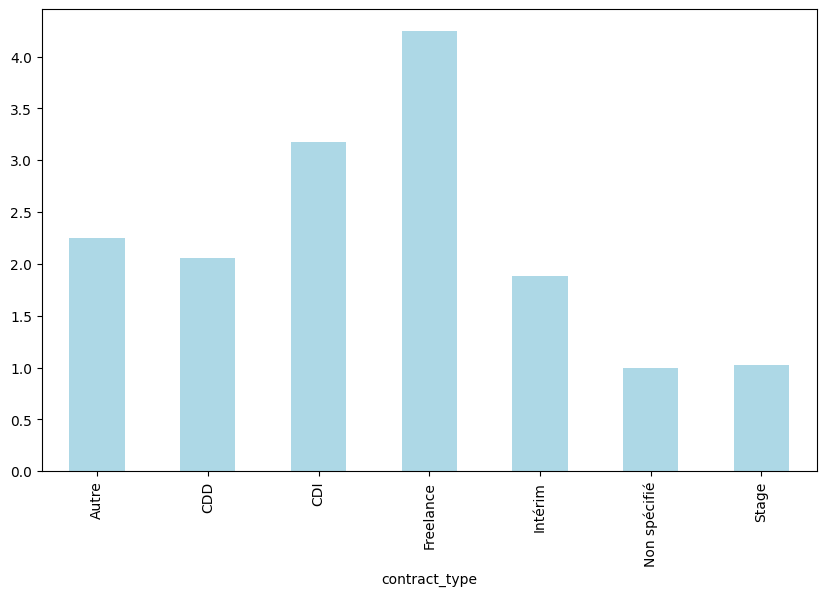

In [31]:
# Je calcule l'expérience minimale moyenne pour chaque type de contrat
df_clean.groupby('contract_type')['exp_years_min'].mean().plot(kind='bar', figsize=(10, 6), color='lightblue')


>  **Interprétation :**
> Je veux savoir si l'expérience demandée change selon le contrat. Je calcule la moyenne d'expérience par type de contrat. Le résultat montre quel contrat demande le plus d'expérience.

Niveau d'Études × Expérience Max (Boxplot)

<Axes: xlabel='education_level'>

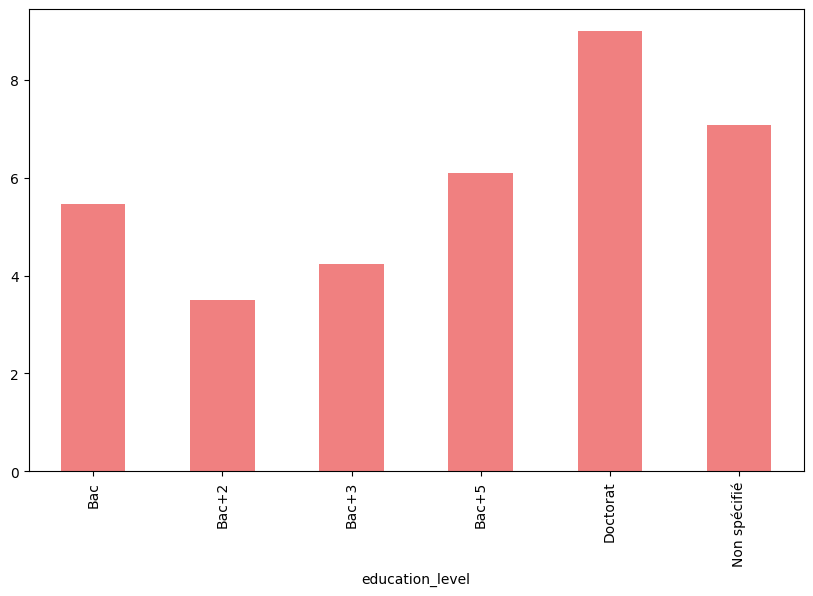

In [32]:
# Je calcule l'expérience maximale moyenne pour chaque niveau d'études
df_clean.groupby('education_level')['exp_years_max'].mean().plot(kind='bar', figsize=(10, 6), color='lightcoral')


>  **Interprétation :**
> Je veux savoir si le niveau d'études influence l'expérience demandée. Je calcule la moyenne par niveau d'études. Le résultat montre un lien clair entre diplôme et expérience exigée.

Région × Expérience Min (Boxplot)

<Axes: xlabel='region'>

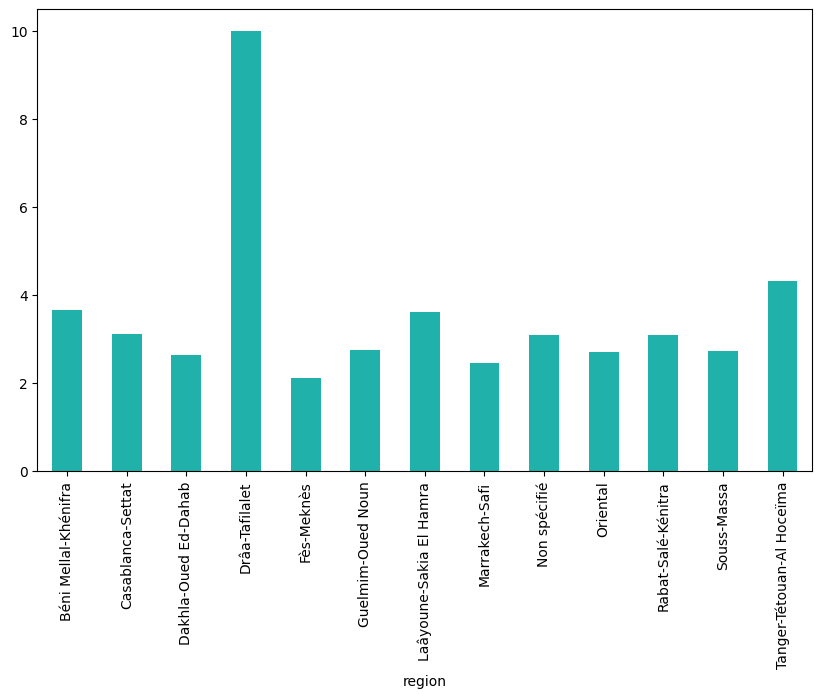

In [33]:
# Je calcule l'expérience minimale moyenne pour chaque région
df_clean.groupby('region')['exp_years_min'].mean().plot(kind='bar', figsize=(10, 6), color='lightseagreen')


>  **Interprétation  :**
> Je veux savoir si l'expérience demandée change selon la région. Je calcule la moyenne d'expérience par région. Le résultat montre les différences régionales du marché.

In [34]:
# Je compte le nombre d'offres pour chaque combinaison (min, max) d'expérience
couples = df.groupby(['exp_years_min', 'exp_years_max']).size().reset_index(name='count')
couples


KeyError: 'exp_years_min'

>  **Interprétation  :**
> Je veux voir quelles combinaisons min/max sont les plus courantes. Je compte le nombre d'offres pour chaque combinaison. Le résultat va me servir pour un graphique plus détaillé.

In [ ]:
# Je recalcule la corrélation entre expérience min et max
r = df['exp_years_min'].corr(df['exp_years_max'])
r


np.float64(0.97759264421705)

>  **Interprétation:**
> Je vérifie une nouvelle fois le chiffre de la corrélation. J'affiche la valeur seule. Le résultat confirme un lien très fort entre les deux variables.

## Partie statistique 

test pearson

In [ ]:
from scipy import stats
import pandas as pd

# TEST DE CORRÉLATION DE PEARSON
# H0 (hypothèse de départ) : pas de corrélation (r = 0)
# H1 (hypothèse alternative) : il existe une corrélation (r différent de 0)
# alpha = 0.05 (seuil de décision)

# Je recharge mon dataset propre
df_clean = pd.read_csv("../data/clean/rekrute_clean_light.csv")
x = df_clean['exp_years_min']
y = df_clean['exp_years_max']

# Je calcule le coefficient de corrélation et la p-value
r, p_value = stats.pearsonr(x, y)

print(f"r = {r:.3f} | p-value = {p_value:.5f}")

# Je compare la p-value au seuil pour prendre une décision
if p_value < 0.05:
    print("→ On rejette H0 : corrélation significative")
else:
    print("→ On ne rejette pas H0 : pas de corrélation significative")


r = 0.978 | p-value = 0.00000
→ On rejette H0 : corrélation significative


>  **Interprétation :**
> Je veux vérifier si le lien entre expérience min et max est réel et pas dû au hasard. Je fais un test de Pearson. Le résultat donne r = 0.978, ce qui prouve une corrélation très forte et significative.

In [ ]:
from scipy import stats
import pandas as pd

# TEST DU CHI-DEUX (Chi-2) D'INDÉPENDANCE
# H0 (hypothèse de départ) : les deux variables sont indépendantes
# H1 (hypothèse alternative) : il existe une association entre les deux variables
# alpha = 0.05 (seuil de décision)

# 1. Je construis un tableau croisé entre type de contrat et mode de travail
table_contingence = pd.crosstab(df_clean['contract_type'], df_clean['work_mode'])

# 2. Je fais le test du Chi-2
chi2, p_value, dof, expected = stats.chi2_contingency(table_contingence)

print(f"Chi2 = {chi2:.3f} | p-value = {p_value:.5f} | ddl = {dof}")

# Je compare la p-value au seuil pour prendre une décision
if p_value < 0.05:
    print("→ On rejette H0 : association significative")
else:
    print("→ On ne rejette pas H0 : pas d'association significative")


Chi2 = 86.681 | p-value = 0.00000 | ddl = 6
→ On rejette H0 : association significative


>  **Interprétation  :**
> Je veux vérifier si le type de contrat influence le mode de travail. Je fais un test du Chi-2. Le résultat prouve qu'il existe bien un lien significatif entre les deux.

In [ ]:
df_test = pd.read_csv("../data/clean/rekrute_clean_light.csv")

NameError: name 'pd' is not defined

In [ ]:
df_test.head()
df_test.shape()
df_test.colomun
df_test.info()
df_test.null()
df_test.duplicate()
df_merge = 

df_test = 
